In [1]:
import numpy as np
import plotly
import plotly.graph_objects as go
import utils
import meshio
import os
import ipywidgets as widgets
import networkx as nx

plotly.offline.init_notebook_mode()

In [2]:
pathglob = 'E:/Projet-M2/2021-m2-ditex-morphotypes/Data/Female/'  # À CHANGER
all_scans = os.listdir(pathglob)

def scan_from_index(i):
    path = pathglob + str(all_scans[i])
    scan = meshio.read(path)
    scan = scan.points
    return scan

In [3]:
min_persistence = 3
index = 274
scan = scan_from_index(index)
PS = utils.points_set(scan)
PS.normalize()
PS.plot(title='Scan '+str(index),
        color='green', opacity=0.5, size=1)

In [4]:
diag = PS.Persistence(min_persistence)

H1 = sorted([h[1][0] for h in diag if h[0] == 1])

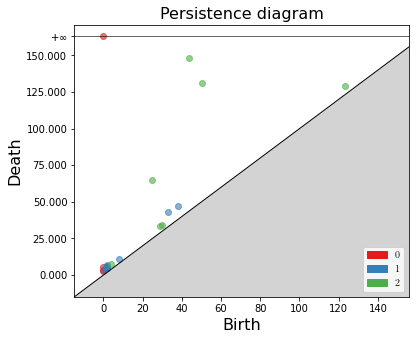

In [5]:
PS.PlotPersistenceDiagram()

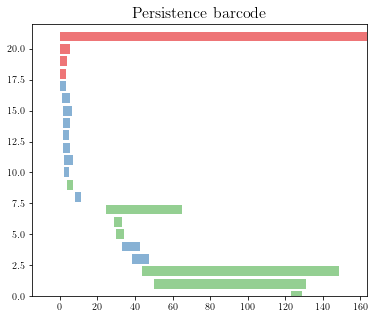

In [6]:
PS.PlotPersistenceBarcode()

In [7]:
def find_homologies(PS, dimension):
    persistence = PS.Persistence()
    filtration = PS.SimplexTree().get_filtration()
    if dimension == 0:
        deaths = []
        for index in range(len(persistence)):
            if persistence[index][0] == 0:
                deaths = [p[1][1] for p in persistence[:index:-1]]
                break
        index = 0
        H0_vertices = []

        for f in filtration:
            time = f[1]

            if index == len(deaths):
                break

            if time == deaths[index]:
                H0_vertices.append(PS.AlphaComplex().get_point(f[0][0]))
                index += 1

        return np.array(H0_vertices).T, deaths

    if dimension == 1:
        births = [h[1][0] for h in diag if h[0] == 1]
        deaths = [h[1][1] for h in diag if h[0] == 1]
        deaths = [deaths[index] for index in np.argsort(births)]
        births = sorted(births)

        FG = nx.Graph()
        paths = []
        index = 0

        for f in filtration:
            length = len(f[0])
            time = f[1]

            if index == len(births):
                break

            if time < births[index]:
                if length == 1:
                    FG.add_node(f[0][0])
                elif length == 2:
                    FG.add_edge(f[0][0], f[0][1], length=np.sqrt(f[1]))
            else:
                chemin = nx.shortest_path(
                    FG, source=f[0][0], target=f[0][1], weight='length')
                paths.append(np.array([PS.AlphaComplex().get_point(
                    vertex) for vertex in chemin+[chemin[0]]]).T)
                FG.add_edge(f[0][0], f[0][1], length=f[1])
                index += 1

        filtration = PS.SimplexTree().get_filtration()
        faces = [[]] * len(deaths)
        index = 0

        for f in filtration:
            length = len(f[0])
            time = f[1]

            if index == len(deaths):
                break

            if time in deaths:
                faces[deaths.index(time)] = np.array(
                    [PS.AlphaComplex().get_point(vertex) for vertex in f[0]+[f[0][0]]]).T
                index += 1

        return paths, faces, np.stack((births, deaths), axis=-1)

    if dimension == 2:
        births = [h[1][0] for h in diag if h[0] == 2]
        deaths = [h[1][1] for h in diag if h[0] == 2]
        deaths = [deaths[index] for index in np.argsort(births)]
        births = sorted(births)

        faces = []
        index = 0

        for f in filtration:
            length = len(f[0])
            time = f[1]

            if index == len(births):
                break

            if time == births[index]:
                faces.append(
                    np.array([PS.AlphaComplex().get_point(vertex) for vertex in f[0]]).T)
                index += 1

        filtration = PS.SimplexTree().get_filtration()
        tetras = [[]] * len(deaths)
        index = 0

        for f in filtration:
            length = len(f[0])
            time = f[1]

            if index == len(deaths):
                break

            if time in deaths:
                tetras[deaths.index(time)] = np.array(
                    [PS.AlphaComplex().get_point(vertex) for vertex in f[0]]).T
                index += 1

        return faces, tetras, np.stack((births, deaths), axis=-1)


In [8]:
def plot_H0(points, deaths, vertices, index):
    data = []
    data.append(go.Scatter3d(
                x=vertices[0],
                y=vertices[1],
                z=vertices[2],
                mode='markers',
                marker=dict(
                    size=0.5,
                    color='blue',
                    opacity=0.25)))

    if len(points) > 0:
        point = points[:, index]
        data.append(go.Scatter3d(
                    x=[point[0]],
                    y=[point[1]],
                    z=[point[2]],
                    mode='markers',
                    marker=dict(
                        size=2.5,
                        color='green',
                        opacity=0.75)))

        fig = go.Figure(data=data)
        fig.update_layout(width=1000, height=1000, title='Homologie H0 n°' +
                          str(index+1)+' - Naissance : 0\tMort : '+str(deaths[index]))
    else:
        fig = go.Figure(data=data)
        fig.update_layout(width=1000, height=1000,
                          title='Il n\'y a pas d\'homologie H0')
    fig.show()


In [9]:
def plot_H1(paths, faces, BanD, index, vertices):
    data = []
    data.append(go.Scatter3d(
                x=vertices[0],
                y=vertices[1],
                z=vertices[2],
                mode='markers',
                marker=dict(
                    size=0.5,
                    color='blue',
                    opacity=0.25)))

    if len(paths) > 0:
        path = paths[index]
        face = faces[index]
        data.append(go.Scatter3d(
                    x=path[0],
                    y=path[1],
                    z=path[2],
                    mode='lines',
                    marker=dict(
                        size=2.5,
                        color='green',
                        opacity=0.75)))

        data.append(go.Mesh3d(
                    x=face[0],
                    y=face[1],
                    z=face[2],
                    color='red',
                    opacity=0.5,
                    showscale=False))

        fig = go.Figure(data=data)
        fig.update_layout(width=1000, height=1000, title='Homologie H1 n°' +
                          str(index+1)+' - Naissance : '+str(BanD[index][0])+'\tMort : '+str(BanD[index][1]))
    else:
        fig = go.Figure(data=data)
        fig.update_layout(width=1000, height=1000,
                          title='Il n\'y a pas d\'homologie H1')
    fig.show()


In [10]:
def plot_H2(faces, tetras, vertices, BanD, index):
    data = []
    data.append(go.Scatter3d(
                x=vertices[0],
                y=vertices[1],
                z=vertices[2],
                mode='markers',
                marker=dict(
                    size=0.5,
                    color='blue',
                    opacity=0.25)))

    if len(faces) > 0:
        face = faces[index]
        tetra = tetras[index]
        data.append(go.Mesh3d(
                    x=face[0],
                    y=face[1],
                    z=face[2],
                    color='green',
                    opacity=0.5,
                    showscale=False))

        data.append(go.Mesh3d(
                    x=tetra[0],
                    y=tetra[1],
                    z=tetra[2],
                    color='red',
                    opacity=0.5,
                    i=[0, 0, 0, 1],
                    j=[1, 2, 3, 2],
                    k=[2, 3, 1, 3],))

        fig = go.Figure(data=data)
        fig.update_layout(width=1000, height=1000, title='Homologie H2 n°'+str(index+1) +
                          ' - Naissance : '+str(BanD[index][0])+'\tMort : '+str(BanD[index][1]))
    else:
        fig = go.Figure(data=data)
        fig.update_layout(width=1000, height=1000,
                          title='Il n\'y a pas d\'homologie H2')
    fig.show()


In [11]:
vertices = np.array(PS.points).T
points, deaths = find_homologies(PS=PS, dimension=0)

paths, faces, BanD = find_homologies(PS=PS, dimension=1)
faces_, tetras, BanD_ = find_homologies(PS=PS, dimension=2)

In [12]:
try:
    nb_points = points.shape[1]
except:
    nb_points = 0

In [13]:

x_widget = widgets.IntSlider(min=min(1, nb_points), max=max(1, nb_points), step=1)
y_widget = widgets.Dropdown(
    options=[('H0', 1), ('H1', 2), ('H2', 3)],
    value=1,
    description='Homology:',
)


def update_x_range(*args):
    if y_widget.value == 1:
        x_widget.max = max(1, nb_points)
        x_widget.min = min(1, nb_points)
    if y_widget.value == 2:
        x_widget.max = max(1, len(paths))
        x_widget.min = min(1, len(paths))
    if y_widget.value == 3:
        x_widget.max = max(1, len(faces_))
        x_widget.min = min(1, len(faces_))


y_widget.observe(update_x_range, 'value')


def plot(Index, homology):
    if homology==1:
        plot_H0(points, deaths, vertices, Index-1)
    elif homology==2:
        plot_H1(paths, faces, BanD, Index-1, vertices)
    else:
        plot_H2(faces_, tetras, vertices, BanD_, Index-1)


widgets.interact(plot, Index=x_widget, homology=y_widget);


interactive(children=(IntSlider(value=1, description='Index', max=3, min=1), Dropdown(description='Homology:',…